load dataset and assign column names

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, trim

spark = SparkSession.builder \
    .appName('CencusIncomeAnalysis') \
    .master('local[*]') \
    .getOrCreate()

df = spark.read.csv('/content/drive/My Drive/adult.csv', header=False, inferSchema=True)

col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
             'marital_status', 'occupation', 'relationship', 'race', 'sex',
             'capital_gain', 'capital_loss', 'hours_per_week',
             'native_country', 'income']

for i, name in enumerate(col_names):
    df = df.withColumnRenamed(f'_c{i}', name)

test if dataset is loaded

In [3]:
print('Rows:', df.count())
print('Columns:', len(df.columns))

Rows: 32561
Columns: 15


remove whitespace and find values with "?"

In [4]:
str_cols = ['workclass','education','marital_status','occupation',
            'relationship','race','sex','native_country','income']

for c in str_cols:
    df = df.withColumn(c, trim(col(c)))

for c in str_cols:
    q_count = df.filter(col(c) == '?').count()
    if q_count > 0:
        print(f'{c}: {q_count} entries with ?')

workclass: 1836 entries with ?
occupation: 1843 entries with ?
native_country: 583 entries with ?


replace "?" with null, fill null values with mode

In [5]:
from pyspark.sql.functions import count, when, sum

In [6]:
df = df.replace('?', None)

def get_mode(df, column):
    return (
        df.filter(col(column).isNotNull())
          .groupBy(column)
          .agg(count("*").alias("freq"))
          .orderBy(col("freq").desc())
          .first()[0]
    )

cols_to_impute = ['workclass', 'occupation', 'native_country']

for c in cols_to_impute:
    mode_val = get_mode(df, c)
    df = df.fillna({c: mode_val})
    print(f'Imputed {c} with mode: {mode_val}')

Imputed workclass with mode: Private
Imputed occupation with mode: Prof-specialty
Imputed native_country with mode: United-States


verify missing values

In [7]:
missing_counts = df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])

missing_counts.show()

+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|education|education_num|marital_status|occupation|relationship|race|sex|capital_gain|capital_loss|hours_per_week|native_country|income|
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+
|  0|        0|     0|        0|            0|             0|         0|           0|   0|  0|           0|           0|             0|             0|     0|
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+



detect duplicates

In [8]:
total = df.count()
unique = df.dropDuplicates().count()
print(f'Total rows: {total}')
print(f'Unique rows: {unique}')
print(f'Duplicates found: {total - unique}')

Total rows: 32561
Unique rows: 32537
Duplicates found: 24


drop duplicates

In [9]:
df = df.dropDuplicates()
print(f'Rows after removal: {df.count()}')

Rows after removal: 32537


dropping unnecessary columns

In [10]:
df = df.drop('education_num', 'fnlwgt')

detecting outliers

In [11]:
num_cols = ['age', 'capital_gain', 'capital_loss', 'hours_per_week']

outlier_bounds = {}

for c in num_cols:
    q1, q3 = df.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_bounds[c] = (lower, upper)

    count_outliers = df.filter((col(c) < lower) | (col(c) > upper)).count()
    print(f"{c}: {count_outliers} outliers")

age: 165 outliers
capital_gain: 2712 outliers
capital_loss: 1519 outliers
hours_per_week: 9002 outliers


handle highly skewed outliers with transformation

In [12]:
from pyspark.sql.functions import log1p

In [13]:
df = df.withColumn("capital_gain", log1p(col("capital_gain")))
df = df.withColumn("capital_loss", log1p(col("capital_loss")))

test for outlier handling

In [14]:
df.select("capital_gain", "capital_loss").describe().show()

+-------+------------------+-------------------+
|summary|      capital_gain|       capital_loss|
+-------+------------------+-------------------+
|  count|             32537|              32537|
|   mean|0.7351627828405516|0.35056347388277714|
| stddev| 2.455561819096337| 1.5851367204628661|
|    min|               0.0|                0.0|
|    max|11.512925464970229|  8.379539026117442|
+-------+------------------+-------------------+



declaring and identifying categorical values

In [15]:
cat_cols = [
    'workclass', 'education', 'marital_status', 'occupation',
    'relationship', 'race', 'sex', 'native_country'
]

transform categorical values into numerical indices including target variable

In [16]:
from pyspark.ml.feature import StringIndexer

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_index", handleInvalid="keep")
    for c in cat_cols
]

label_indexer = StringIndexer(inputCol='income', outputCol='label')

one hot encoding to convert numerical variables into binary vectors

In [17]:
from pyspark.ml.feature import OneHotEncoder

In [18]:
encoder = OneHotEncoder(
    inputCols=[c + "_index" for c in cat_cols],
    outputCols=[c + "_vec" for c in cat_cols]
)

Selecting initial numerical columns and combine them with encoded caterical values to create a single vector

In [19]:
from pyspark.ml.feature import VectorAssembler

In [20]:
num_cols = [
    'age', 'capital_gain', 'capital_loss', 'hours_per_week'
]

In [21]:
assembler = VectorAssembler(
    inputCols=[c + "_vec" for c in cat_cols] + num_cols,
    outputCol="features"
)

pipeline to sequentially run indexing, encoding and feature assembling

In [22]:
from pyspark.ml import Pipeline

In [23]:
pipeline = Pipeline(stages=indexers + [label_indexer, encoder, assembler])

df_final = pipeline.fit(df).transform(df)

test to verify encoding and feature assembling

In [24]:
df_final.select('features', 'label').show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|(103,[0,8,24,41,4...|  0.0|
|(103,[0,8,24,37,4...|  0.0|
|(103,[0,9,26,32,4...|  0.0|
|(103,[0,9,28,31,4...|  0.0|
|(103,[0,8,24,38,4...|  0.0|
+--------------------+-----+
only showing top 5 rows


**ANALYSIS AND VISUALIZATIONS**

transform dataset into pandas

In [25]:
df_pandas = df.toPandas()

bar chart for income distribution

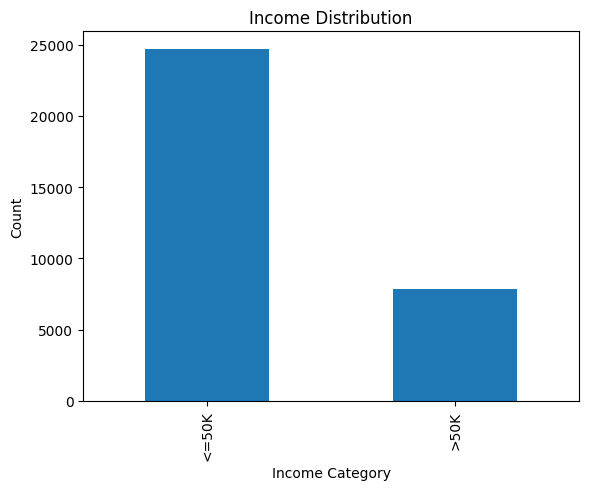

In [26]:
import matplotlib.pyplot as plt

df_pandas['income'].value_counts().plot(kind='bar')
plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()

histogram for age distribution

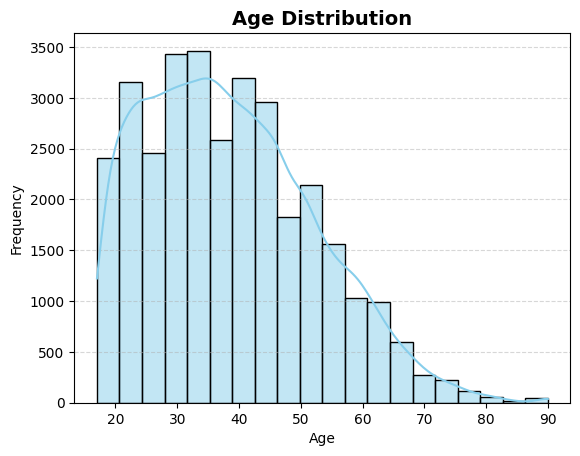

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_pandas['age'], bins=20, kde=True, color='skyblue', edgecolor='black')

plt.title("Age Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)  # Subtle grid
plt.show()

boxplot to visualize outliers

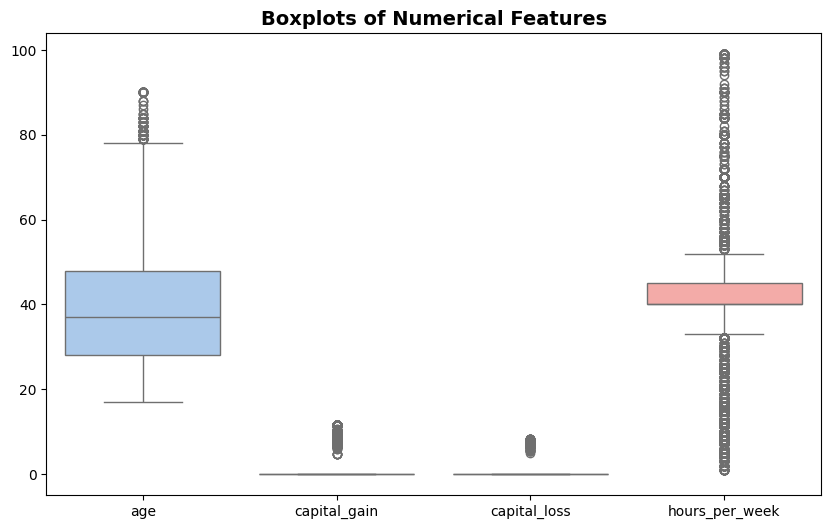

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['age', 'capital_gain', 'capital_loss', 'hours_per_week']
plt.figure(figsize=(10,6))
sns.boxplot(data=df_pandas[num_cols], palette='pastel')
plt.title("Boxplots of Numerical Features", fontsize=14, fontweight='bold')
plt.xticks(fontsize=10)
plt.show()

 for correlation analysis

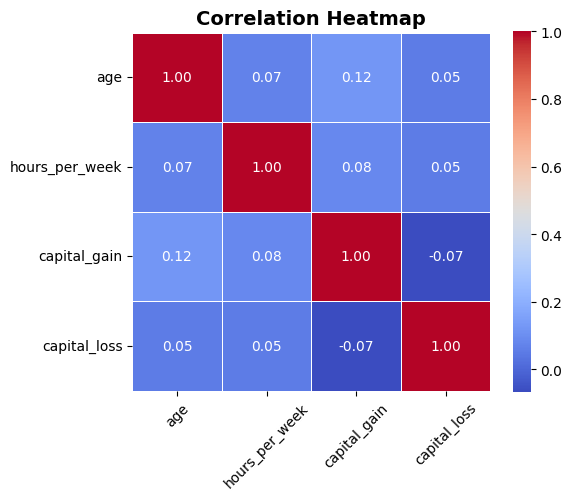

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = ['age', 'hours_per_week', 'capital_gain', 'capital_loss']

# Compute correlation matrix
corr_matrix = df_pandas[num_cols].corr()

# Plot heatmap with Seaborn
plt.figure(figsize=(6,5))  # Compact yet readable
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True, linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

violinplot for age and income

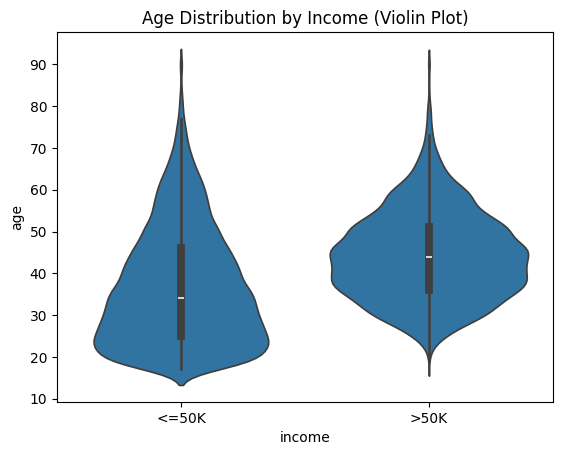

In [30]:
import seaborn as sns

sns.violinplot(x='income', y='age', data=df_pandas)
plt.title("Age Distribution by Income (Violin Plot)")
plt.show()

grouped bar chart for education and income

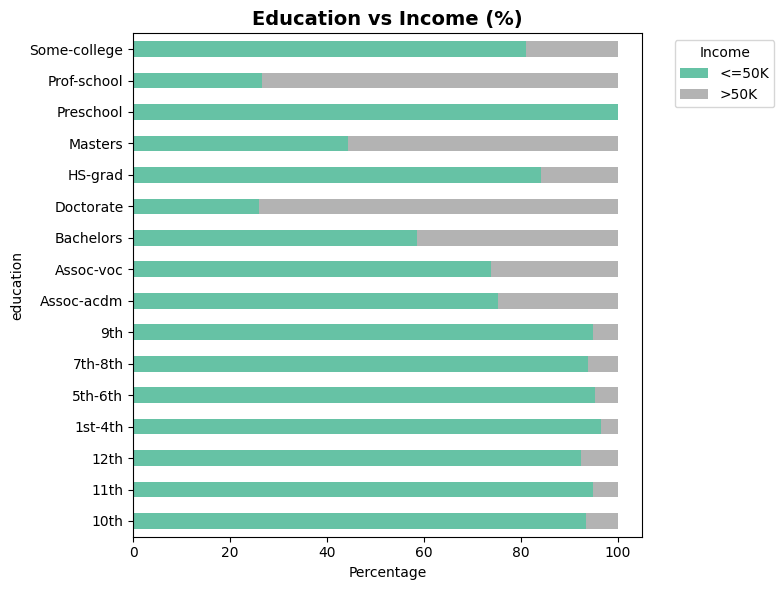

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

edu_income = pd.crosstab(df_pandas['education'], df_pandas['income'])
edu_income_pct = edu_income.div(edu_income.sum(axis=1), axis=0) * 100

# Plotting
edu_income_pct.plot(kind='barh', stacked=True, figsize=(8, 6), colormap='Set2')
plt.title("Education vs Income (%)", fontsize=14, fontweight='bold')
plt.legend(title='Income', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Percentage", fontsize=10)
plt.tight_layout()
plt.show()

check class imbalance in income

In [32]:
# Count target class distribution
df.groupBy("income").count().show()

+------+-----+
|income|count|
+------+-----+
| <=50K|24698|
|  >50K| 7839|
+------+-----+



**Modelling & Evaluation**

In [33]:
# Imports
from pyspark.ml.feature import StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

indexing target column

In [34]:
label_indexer = StringIndexer(inputCol="income", outputCol="label_numeric")
df_final_indexed = label_indexer.fit(df_final).transform(df_final)

split

In [35]:
train_data, test_data = df_final_indexed.randomSplit([0.8, 0.2], seed=42)

feature scaling

In [36]:
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
scaler_model = scaler.fit(train_data)
train_scaled = scaler_model.transform(train_data)
test_scaled = scaler_model.transform(test_data)

models

In [37]:
# Logistic Regression
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label")
lr_model = lr.fit(train_scaled)
lr_pred = lr_model.transform(test_scaled)

# Decision Tree
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=10)
dt_model = dt.fit(train_data)
dt_pred = dt_model.transform(test_data)

# Random Forest
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, maxDepth=10)
rf_model = rf.fit(train_data)
rf_pred = rf_model.transform(test_data)

evaluation

In [38]:
def evaluate_model(predictions):
    metrics = ["accuracy", "f1", "weightedPrecision", "weightedRecall"]
    results = {}
    for m in metrics:
        evaluator = MulticlassClassificationEvaluator(labelCol="label",
                                                      predictionCol="prediction",
                                                      metricName=m)
        results[m] = evaluator.evaluate(predictions)
    return results

# Evaluate all models
lr_metrics = evaluate_model(lr_pred)
dt_metrics = evaluate_model(dt_pred)
rf_metrics = evaluate_model(rf_pred)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1-score", "Precision", "Recall"],
    "Logistic Regression": [
        lr_metrics["accuracy"],
        lr_metrics["f1"],
        lr_metrics["weightedPrecision"],
        lr_metrics["weightedRecall"]
    ],
    "Decision Tree": [
        dt_metrics["accuracy"],
        dt_metrics["f1"],
        dt_metrics["weightedPrecision"],
        dt_metrics["weightedRecall"]
    ],
    "Random Forest": [
        rf_metrics["accuracy"],
        rf_metrics["f1"],
        rf_metrics["weightedPrecision"],
        rf_metrics["weightedRecall"]
    ]
})

metrics_df = metrics_df.round(4)
metrics_df

,Metric,Logistic Regression,Decision Tree,Random Forest
0,Accuracy,0.8441,0.8451,0.8455
1,F1-score,0.8376,0.8342,0.8313
2,Precision,0.8370,0.8383,0.8414
3,Recall,0.8441,0.8451,0.8455


confusion matrix heatmap

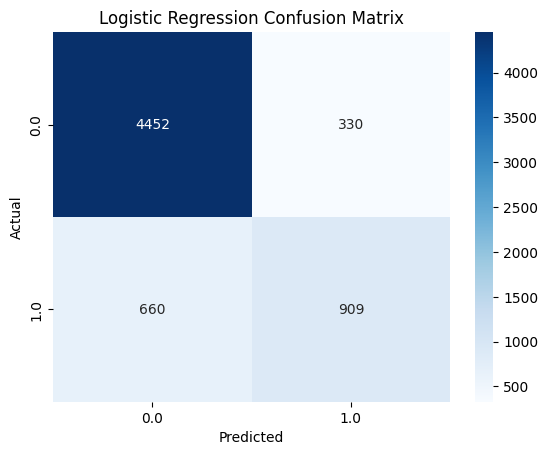

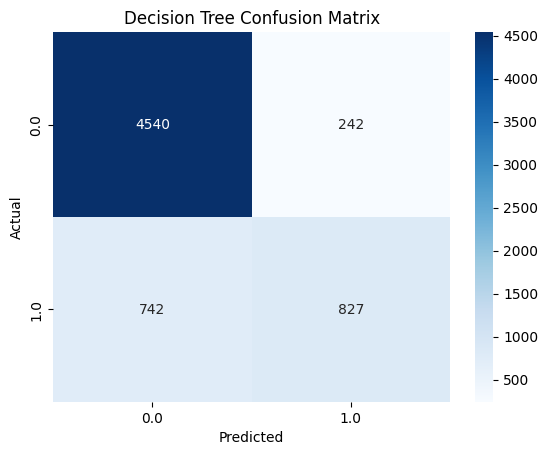

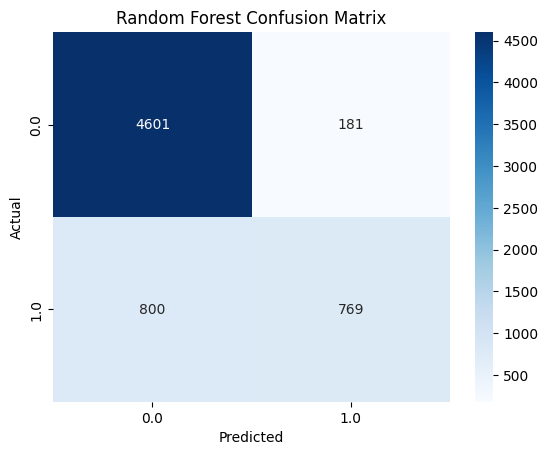

In [39]:
def plot_confusion_matrix(predictions, title):
    # Convert Spark DF to Pandas
    cm_df = predictions.select("label", "prediction").toPandas()
    conf_matrix = pd.crosstab(cm_df["label"], cm_df["prediction"])

    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Plot for all models
plot_confusion_matrix(lr_pred, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(dt_pred, "Decision Tree Confusion Matrix")
plot_confusion_matrix(rf_pred, "Random Forest Confusion Matrix")